# Bloque 3 - NLP y modelo pre-entrenado

## Ciberacoso en tweets colombianos

Este notebook analiza un corpus textual colombiano de tweets etiquetados como ciberacoso o no ciberacoso.

**Dataset:** Colombian Spanish Cyberbullying Dataset

**Archivo local:** `corpus_ciberacoso_colombiano.csv`

**Variable objetivo:** `ciberacoso`

## Objetivos del bloque

1. Cargar un corpus textual colombiano con más de 200 documentos.
2. Tokenizar textos con `RegexTokenizer` y remover stop words en español.
3. Calcular total de tokens, vocabulario, TTR y hapax legomena.
4. Aplicar CountVectorizer + IDF y analizar palabras relevantes.
5. Entrenar Regresión Logística con TF-IDF.
6. Comparar el modelo TF-IDF con un modelo pre-entrenado de Hugging Face.

## 1. Configuración inicial
Se importan librerías de PySpark, NLP, modelos, métricas y gráficos.

In [1]:
from pathlib import Path
import re

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, DoubleType
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spark = (
    SparkSession.builder
    .appName("bloque3_nlp_ciberacoso_colombiano")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

## Parte A - Preparación del corpus

### 2. Carga del corpus

In [2]:
possible_paths = [
    Path("bloque3_nlp/corpus_ciberacoso_colombiano.csv"),
    Path("corpus_ciberacoso_colombiano.csv"),
    Path("../bloque3_nlp/corpus_ciberacoso_colombiano.csv"),
]

DATA_PATH = next(path for path in possible_paths if path.exists())
print(f"Archivo utilizado: {DATA_PATH.resolve()}")

schema = StructType([
    StructField("author", StringType(), True),
    StructField("categoria", DoubleType(), True),
    StructField("ciberacoso", DoubleType(), True),
    StructField("texto", StringType(), True),
    StructField("Unnamed: 4", StringType(), True),
])

df_raw = (
    spark.read
    .option("header", True)
    .option("multiLine", True)
    .option("escape", '"')
    .option("encoding", "UTF-8")
    .schema(schema)
    .csv(str(DATA_PATH))
)

df = (
    df_raw
    .select("author", "categoria", "ciberacoso", "texto")
    .filter(F.col("texto").isNotNull() & F.col("ciberacoso").isNotNull())
    .withColumn("label", F.col("ciberacoso").cast("double"))
    .withColumn("texto_limpio", F.lower(F.regexp_replace(F.col("texto"), r"http\S+|www\S+|@\w+|#", " ")))
    .withColumn("longitud_caracteres", F.length("texto"))
    .withColumn("doc_id", F.monotonically_increasing_id())
)

df.cache()
print(f"Documentos válidos: {df.count():,}")
df.select("categoria", "label", "longitud_caracteres").show(8)

Archivo utilizado: /home/jovyan/work/bloque3_nlp/corpus_ciberacoso_colombiano.csv
Documentos válidos: 2,565
+---------+-----+-------------------+
|categoria|label|longitud_caracteres|
+---------+-----+-------------------+
|      4.0|  1.0|                218|
|      2.0|  1.0|                 27|
|      4.0|  1.0|                129|
|      2.0|  1.0|                 34|
|      4.0|  1.0|                 72|
|      2.0|  1.0|                 33|
|      4.0|  1.0|                 39|
|      2.0|  1.0|                 47|
+---------+-----+-------------------+
only showing top 8 rows



Se carga el corpus de ciberacoso colombiano, se eliminan registros sin texto o etiqueta y se crea `label`. Quedan 2.565 documentos válidos.

In [3]:
df.groupBy("label").count().withColumn("porcentaje", F.round(F.col("count") / df.count() * 100, 2)).orderBy("label").show()
df.groupBy("categoria").count().orderBy("categoria").show()
df.select("longitud_caracteres").describe().show()

+-----+-----+----------+
|label|count|porcentaje|
+-----+-----+----------+
|  0.0| 1282|     49.98|
|  1.0| 1283|     50.02|
+-----+-----+----------+

+---------+-----+
|categoria|count|
+---------+-----+
|      0.0| 1282|
|      1.0|  101|
|      2.0|  688|
|      3.0|  137|
|      4.0|  357|
+---------+-----+

+-------+-------------------+
|summary|longitud_caracteres|
+-------+-------------------+
|  count|               2565|
|   mean|  88.44834307992203|
| stddev| 59.462308639798046|
|    min|                  7|
|    max|                500|
+-------+-------------------+



Se revisa la distribución de clases y categorías. La variable `label` está balanceada: 49,98% no ciberacoso y 50,02% ciberacoso. La longitud promedio de los tweets es de 88,45 caracteres.

### 3. Tokenización y stop words

In [4]:
tokenizer = RegexTokenizer(
    inputCol="texto_limpio",
    outputCol="tokens",
    pattern="[^a-záéíóúñü]+",
    gaps=True,
    minTokenLength=2,
)

stopwords_es = StopWordsRemover.loadDefaultStopWords("spanish")
stopwords_extra = ["q", "pa", "ud", "usted", "vos", "mas", "si", "asi", "solo", "tan", "ser", "va", "voy"]

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="tokens_limpios",
    stopWords=list(set(stopwords_es + stopwords_extra)),
)

df_tokens = remover.transform(tokenizer.transform(df)).cache()
df_tokens.select("label", "tokens_limpios").show(5, truncate=80)

+-----+--------------------------------------------------------------------------------+
|label|                                                                  tokens_limpios|
+-----+--------------------------------------------------------------------------------+
|  1.0|[dalai, lama, pedófilo, escuda, detrás, ideología, religiosa, aprovechándose,...|
|  1.0|                                                    [siga, paseo, bruja, inútil]|
|  1.0|[fácil, terroristas, mediáticos, revistasemana, pregunten, niños, guerrilla, ...|
|  1.0|                                                        [gonorrea, persona, sos]|
|  1.0|                       [padre, pobre, rata, murió, siendo, investigado, mentira]|
+-----+--------------------------------------------------------------------------------+
only showing top 5 rows



Se tokeniza el texto y se eliminan stopwords en español.

### 4. Estadística descriptiva del corpus: tokens, vocabulario, TTR y hapax

In [5]:
tokens_exploded = df_tokens.select("label", F.explode("tokens_limpios").alias("token"))
freq_tokens = tokens_exploded.groupBy("token").count().orderBy(F.desc("count")).cache()

total_documentos = df_tokens.count()
total_tokens = tokens_exploded.count()
vocabulario = freq_tokens.count()
ttr = vocabulario / total_tokens
hapax = freq_tokens.filter(F.col("count") == 1).count()

print(f"Total de documentos: {total_documentos:,}")
print(f"Total de tokens limpios: {total_tokens:,}")
print(f"Tamaño del vocabulario: {vocabulario:,}")
print(f"TTR vocabulario/tokens: {ttr:.4f}")
print(f"Hapax legomena: {hapax:,}")
print(f"Porcentaje del vocabulario que es hapax: {hapax / vocabulario * 100:.2f}%")

freq_tokens.show(20, truncate=False)

Total de documentos: 2,565
Total de tokens limpios: 20,055
Tamaño del vocabulario: 8,075
TTR vocabulario/tokens: 0.4026
Hapax legomena: 5,233
Porcentaje del vocabulario que es hapax: 64.80%
+-----------+-----+
|token      |count|
+-----------+-----+
|rata       |72   |
|vida       |71   |
|hijueputa  |67   |
|hoy        |65   |
|así        |64   |
|mierda     |62   |
|madre      |58   |
|malparido  |56   |
|puta       |56   |
|puede      |55   |
|hace       |55   |
|bien       |52   |
|hacer      |51   |
|colombia   |50   |
|día        |50   |
|ver        |49   |
|hijo       |48   |
|guerrillero|48   |
|cómo       |47   |
|gente      |46   |
+-----------+-----+
only showing top 20 rows



Se calculan estadísticas del corpus. Hay 20.055 tokens limpios, 8.075 términos en el vocabulario, TTR de 0,4026 y 5.233 hapax. El alto porcentaje de hapax es normal en tweets por errores, nombres y expresiones poco repetidas.

## Parte B - TF-IDF y análisis estadístico

### 5. Vectorización con CountVectorizer + IDF

In [6]:
cv = CountVectorizer(inputCol="tokens_limpios", outputCol="tf", vocabSize=3000, minDF=2)
idf = IDF(inputCol="tf", outputCol="tfidf")

cv_model = cv.fit(df_tokens)
df_tf = cv_model.transform(df_tokens)
idf_model = idf.fit(df_tf)
df_tfidf = idf_model.transform(df_tf).cache()

vocab = cv_model.vocabulary
print(f"Vocabulario usado por CountVectorizer: {len(vocab):,}")
df_tfidf.select("label", "tf", "tfidf").show(3, truncate=False)

Vocabulario usado por CountVectorizer: 2,783
+-----+--------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|tf                                                                                          |tfidf                                                                                                                                                                                                                                  |
+-----+--------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Se vectoriza el texto con CountVectorizer e IDF. El vocabulario usado por el modelo tiene 2.783 términos, porque se filtran palabras muy raras con `minDF=2`.

### 6. Palabras más frecuentes por TF crudo

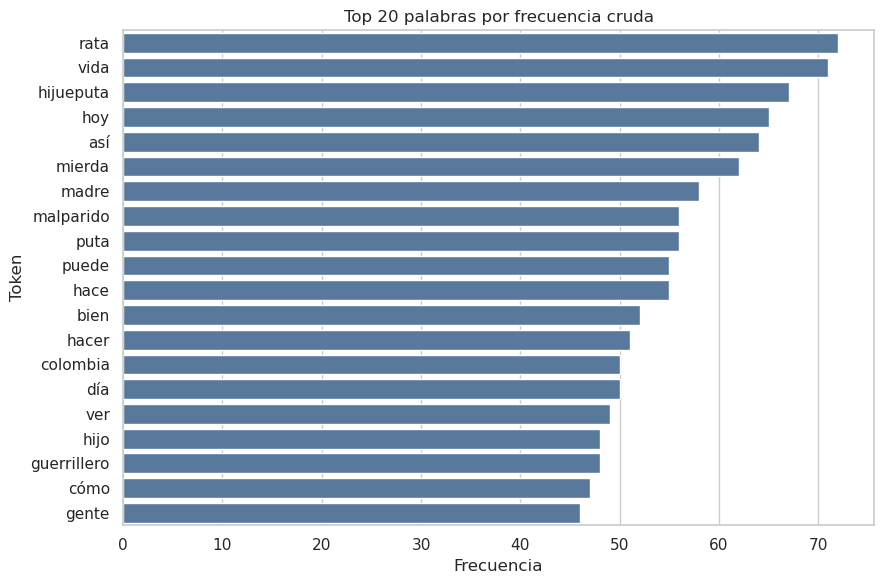

,token,count
0,rata,72
1,vida,71
2,hijueputa,67
3,hoy,65
4,así,64
5,mierda,62
6,madre,58
7,malparido,56
8,puta,56
9,puede,55


In [7]:
top_tf_pd = freq_tokens.limit(20).toPandas()

plt.figure(figsize=(9, 6))
sns.barplot(data=top_tf_pd, y="token", x="count", color="#4C78A8")
plt.title("Top 20 palabras por frecuencia cruda")
plt.xlabel("Frecuencia")
plt.ylabel("Token")
plt.tight_layout()
plt.show()

top_tf_pd.head(10)

### 7. Palabras con mayor TF-IDF promedio por categoría

In [8]:
tfidf_rows = (
    df_tfidf
    .select("label", F.posexplode(vector_to_array("tfidf")).alias("idx", "tfidf_value"))
    .filter(F.col("tfidf_value") > 0)
    .groupBy("label", "idx")
    .agg(F.avg("tfidf_value").alias("tfidf_promedio"))
)

vocab_df = spark.createDataFrame([(i, token) for i, token in enumerate(vocab)], ["idx", "token"])

tfidf_top = (
    tfidf_rows.join(vocab_df, on="idx")
    .withColumn("rn", F.row_number().over(Window.partitionBy("label").orderBy(F.desc("tfidf_promedio"))))
    .filter(F.col("rn") <= 15)
    .orderBy("label", "rn")
)

tfidf_top.show(40, truncate=False)

+----+-----+------------------+------------+---+
|idx |label|tfidf_promedio    |token       |rn |
+----+-----+------------------+------------+---+
|811 |0.0  |13.502982513014944|afectos     |1  |
|833 |0.0  |13.502982513014944|llamadas    |2  |
|846 |0.0  |13.502982513014944|char        |3  |
|1126|0.0  |13.502982513014944|sentimientos|4  |
|1277|0.0  |13.502982513014944|iniciar     |5  |
|1331|0.0  |13.502982513014944|ave         |6  |
|1400|0.0  |13.502982513014944|conseguir   |7  |
|1470|0.0  |13.502982513014944|pastor      |8  |
|1509|0.0  |13.502982513014944|juicio      |9  |
|664 |0.0  |12.927618368111382|actual      |10 |
|960 |0.0  |12.927618368111382|sirve       |11 |
|981 |0.0  |12.927618368111382|creer       |12 |
|585 |0.0  |12.481331265482963|pasos       |13 |
|587 |0.0  |10.40110938790247 |parecer     |14 |
|1111|0.0  |10.127236884761208|amantes     |15 |
|770 |1.0  |16.87872814126868 |regrese     |1  |
|308 |1.0  |15.145860189868817|polo        |2  |
|65  |1.0  |13.77602

## Parte C - Clasificación con TF-IDF

### 8. Regresión Logística con TF-IDF

In [9]:
train, test = df_tfidf.select("doc_id", "tfidf", "label", "texto").randomSplit([0.8, 0.2], seed=42)

lr = LogisticRegression(featuresCol="tfidf", labelCol="label", maxIter=40, regParam=0.01)
lr_model = lr.fit(train)
pred_tfidf = lr_model.transform(test).cache()

print(f"Train: {train.count():,}")
print(f"Test: {test.count():,}")
print("Modelo TF-IDF entrenado correctamente.")

Train: 2,104
Test: 461
Modelo TF-IDF entrenado correctamente.


Se divide el corpus en train y test, y se entrena Regresión Logística con vectores TF-IDF. El conjunto de entrenamiento tiene 2.104 documentos y el de prueba 461.

In [10]:
accuracy_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
auc_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

accuracy_tfidf = accuracy_eval.evaluate(pred_tfidf)
f1_tfidf = f1_eval.evaluate(pred_tfidf)
auc_tfidf = auc_eval.evaluate(pred_tfidf)

print(f"Accuracy TF-IDF: {accuracy_tfidf:.4f}")
print(f"F1 TF-IDF: {f1_tfidf:.4f}")
print(f"AUC TF-IDF: {auc_tfidf:.4f}")

Accuracy TF-IDF: 0.9046
F1 TF-IDF: 0.9044
AUC TF-IDF: 0.9510


Se evalúa el modelo TF-IDF. Los resultados son altos: accuracy 0,9046, F1 0,9044 y AUC 0,9510. Esto indica que el vocabulario del corpus separa bien ciberacoso y no ciberacoso.

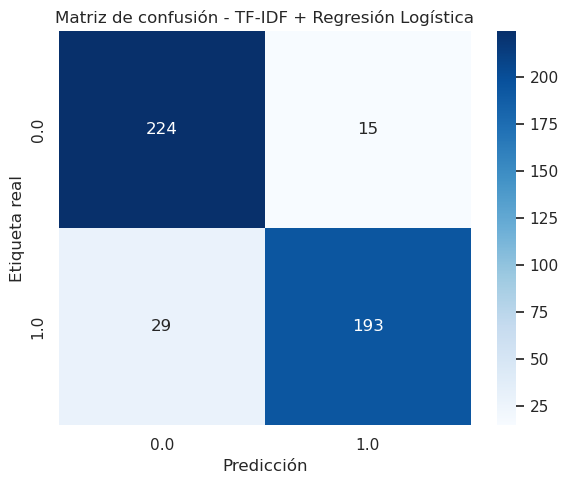

prediction,0.0,1.0
label,,
0.0,224,15
1.0,29,193


In [11]:
confusion_tfidf = pred_tfidf.groupBy("label", "prediction").count().toPandas()
confusion_pivot = confusion_tfidf.pivot(index="label", columns="prediction", values="count").fillna(0)
confusion_pivot = confusion_pivot.reindex(index=[0.0, 1.0], columns=[0.0, 1.0], fill_value=0)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Matriz de confusión - TF-IDF + Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.tight_layout()
plt.show()

confusion_pivot

La matriz de confusión muestra 224 verdaderos negativos y 193 verdaderos positivos. Hay 15 falsos positivos y 29 falsos negativos, por lo que el modelo se equivoca poco en el test.

### 9. Coeficientes: palabras que predicen cada clase

In [12]:
coef = lr_model.coefficients.toArray()

coef_pd = pd.DataFrame({"token": vocab, "coeficiente": coef})
top_ciberacoso = coef_pd.sort_values("coeficiente", ascending=False).head(20)
top_no_ciberacoso = coef_pd.sort_values("coeficiente", ascending=True).head(20)

print("Palabras asociadas a ciberacoso (coeficiente positivo):")
display(top_ciberacoso)

print("Palabras asociadas a no ciberacoso (coeficiente negativo):")
display(top_no_ciberacoso)

Palabras asociadas a ciberacoso (coeficiente positivo):


,token,coeficiente
203,suicidese,0.739514
46,lameculos,0.709131
107,bruja,0.666844
301,bandida,0.665012
0,rata,0.663547
162,mugroso,0.648472
47,imbécil,0.641771
6,madre,0.630439
31,analfabeta,0.612709
139,cacorro,0.604578


Palabras asociadas a no ciberacoso (coeficiente negativo):


,token,coeficiente
2151,soledad,-0.687875
1872,hernandez,-0.556427
2157,paro,-0.526917
2220,radicales,-0.511678
2246,gabinete,-0.504959
2777,valores,-0.501136
2468,soportar,-0.493027
1640,pregunta,-0.493027
2053,cirujano,-0.491470
1165,continuar,-0.483793


Los coeficientes positivos corresponden a palabras que empujan hacia ciberacoso y los negativos, hacia no ciberacoso. 

## Parte D - Modelo pre-entrenado de Hugging Face

Se usa `pysentimiento`, basado en RoBERTuito, con la tarea `hate_speech` en español. No es exactamente el mismo concepto que ciberacoso, pero es un modelo apropiado para detectar lenguaje ofensivo, agresivo u odioso en español. 

In [13]:
from pysentimiento import create_analyzer

analyzer = create_analyzer(task="hate_speech", lang="es")

pdf_hf = df.select("doc_id", "texto", "label").toPandas()

def predecir_hf(texto):
    resultado = analyzer.predict(str(texto))
    prob_hateful = float(resultado.probas.get("hateful", 0.0))
    return 1.0 if prob_hateful >= 0.5 else 0.0, prob_hateful

predicciones_hf = [predecir_hf(texto) for texto in pdf_hf["texto"]]
pdf_hf["pred_hf"] = [p[0] for p in predicciones_hf]
pdf_hf["prob_hateful"] = [p[1] for p in predicciones_hf]

pdf_hf.head()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,doc_id,texto,label,pred_hf,prob_hateful
0,0,Dalai Lama es un pedófilo que se escuda detrás...,1.0,0.0,0.012630
1,1,Siga de paseo bruja inútil!,1.0,1.0,0.979906
2,2,"Fácil, que los terroristas mediáticos de \nRev...",1.0,1.0,0.566256
3,3,Que gonorrea de persona sos vos!!!,1.0,1.0,0.607780
4,4,Su padre es una pobre rata que se murió siendo...,1.0,0.0,0.126689


Se carga el modelo pre-entrenado de Hugging Face mediante `pysentimiento`. El modelo predice hate speech en español.

In [14]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

pred_tfidf_test_pd = pred_tfidf.select("doc_id", "label", F.col("prediction").alias("pred_tfidf")).toPandas()
comparacion_test = pred_tfidf_test_pd.merge(pdf_hf[["doc_id", "pred_hf"]], on="doc_id", how="left")

accuracy_hf = accuracy_score(comparacion_test["label"], comparacion_test["pred_hf"])
f1_hf = f1_score(comparacion_test["label"], comparacion_test["pred_hf"])

comparacion_modelos = pd.DataFrame([
    {"modelo": "TF-IDF + Regresión Logística", "accuracy": accuracy_tfidf, "f1": f1_tfidf},
    {"modelo": "Hugging Face RoBERTuito", "accuracy": accuracy_hf, "f1": f1_hf},
])

comparacion_modelos

,modelo,accuracy,f1
0,TF-IDF + Regresión Logística,0.904555,0.90436
1,Hugging Face RoBERTuito,0.616052,0.40000


TF-IDF obtiene accuracy 0,9046 y F1 0,9044 y RoBERTuito obtiene accuracy 0,6161 y F1 0,4000. El modelo local funciona mejor porque fue entrenado con este corpus.

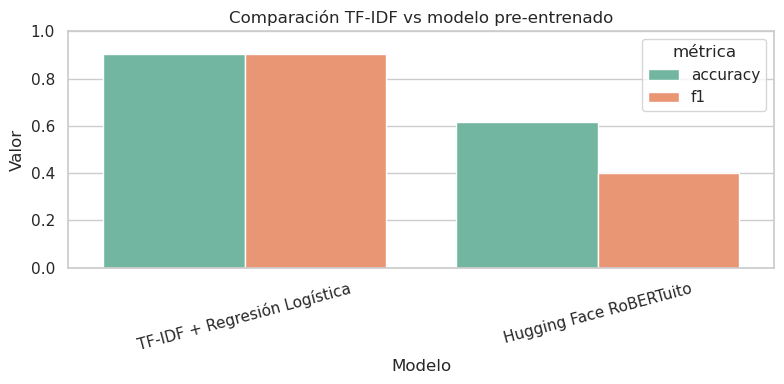

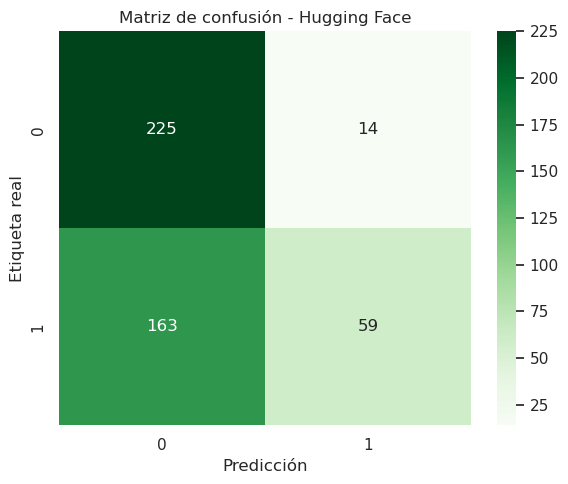

In [15]:
plt.figure(figsize=(8, 4))
comparacion_larga = comparacion_modelos.melt(id_vars="modelo", value_vars=["accuracy", "f1"], var_name="métrica", value_name="valor")
sns.barplot(data=comparacion_larga, x="modelo", y="valor", hue="métrica")
plt.title("Comparación TF-IDF vs modelo pre-entrenado")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

cm_hf = confusion_matrix(comparacion_test["label"], comparacion_test["pred_hf"], labels=[0.0, 1.0])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_hf, annot=True, fmt=".0f", cmap="Greens", xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Matriz de confusión - Hugging Face")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.tight_layout()
plt.show()

La comparación muestra que el modelo pre-entrenado no se ajusta tan bien a las etiquetas específicas de este dataset.

### 10. Cinco casos difíciles

In [16]:
casos_dificiles = pd.DataFrame({
    "caso": [
        "No estoy insultando, pero esa persona siempre escribe cosas absurdas.",
        "Claro, genio, qué gran idea arruinar todo otra vez.",
        "No deberíamos atacar a nadie por pensar diferente.",
        "Ese comentario fue fuerte, pero no necesariamente una amenaza.",
        "Ojalá aprenda a respetar antes de volver a hablar así.",
    ]
})

spark_casos = spark.createDataFrame(casos_dificiles.rename(columns={"caso": "texto"}))
spark_casos = spark_casos.withColumn("texto_limpio", F.lower(F.regexp_replace(F.col("texto"), r"http\S+|www\S+|@\w+|#", " ")))
casos_tokens = remover.transform(tokenizer.transform(spark_casos))
casos_tfidf = idf_model.transform(cv_model.transform(casos_tokens))
casos_pred_tfidf = lr_model.transform(casos_tfidf).select("texto", F.col("prediction").alias("pred_tfidf")).toPandas()

casos_dificiles["pred_tfidf"] = casos_pred_tfidf["pred_tfidf"]
casos_dificiles["pred_hf"] = [predecir_hf(texto)[0] for texto in casos_dificiles["caso"]]
casos_dificiles

,caso,pred_tfidf,pred_hf
0,"No estoy insultando, pero esa persona siempre ...",1.0,0.0
1,"Claro, genio, qué gran idea arruinar todo otra...",0.0,0.0
2,No deberíamos atacar a nadie por pensar difere...,0.0,0.0
3,"Ese comentario fue fuerte, pero no necesariame...",1.0,0.0
4,Ojalá aprenda a respetar antes de volver a hab...,1.0,0.0


Se prueban cinco casos difíciles con ambos modelos. Los resultados muestran que TF-IDF puede marcar como ciberacoso algunas frases ambiguas, mientras RoBERTuito tiende a ser más conservador en esos ejemplos.

## Conclusiones del Bloque 3

1. El corpus contiene 2.565 tweets colombianos válidos etiquetados. Después de tokenizar y remover stop words se obtuvieron 20.055 tokens limpios, un vocabulario de 8.075 términos y un TTR de 0,4026.

2. TF-IDF permite interpretar el vocabulario asociado a cada clase. A diferencia de un modelo profundo, la Regresión Logística permite mirar coeficientes y revisar qué palabras empujan la predicción hacia ciberacoso o no ciberacoso. El modelo TF-IDF obtuvo accuracy de 0,9046, F1 de 0,9044 y AUC de 0,9510 en el conjunto de prueba.

3. El modelo pre-entrenado sirve como comparación externa, pero no reemplaza necesariamente al modelo entrenado en este corpus. RoBERTuito obtuvo accuracy de 0,6161 y F1 de 0,4000 sobre el mismo conjunto de prueba. La diferencia se explica porque RoBERTuito fue entrenado para hate speech en español, no específicamente para ciberacoso colombiano ni para las etiquetas de este dataset.

4. Para producción recomendaría un enfoque combinado. Primero usar un modelo pre-entrenado como punto de partida, pero ajustarlo o validarlo con datos colombianos etiquetados.

## Limitaciones

- Los textos son tweets, por lo que son cortos y dependen mucho del contexto.
- El modelo pre-entrenado detecta hate speech, que no es exactamente lo mismo que ciberacoso.
- Algunas palabras ofensivas pueden aparecer en citas, ironías o discusiones no necesariamente acosadoras.
- No se hizo ajuste fino del modelo Hugging Face, solo se aplicó como modelo externo de comparación.